In [1]:
# Download the sentence transformers package, which we will be using to encode book descriptions/synopses as vectors
# Only need to do once. Uncomment to download yourself 
# %pip install -U sentence_transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

We want to apply some natural language processing techniques to the various string fields that we have. A past project used this thing called SentenceTransformer, which for us will be some blackbox
$$
    \operatorname{SentenceTransformer} : \{ \text{text} \} \to \R^{384} 
$$
which is "continuous" in the sense that sentences that talk about similar things/topics should go to vectors which are close together in some way.

In [3]:
from sentence_transformers import SentenceTransformer

transformer = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
books = pd.read_csv('../data/final_book_dataset_cleaned.csv', sep = '\t', 
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
})

books

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus
0,9372,The Long Loud Silence,Wilson Tucker,1954,1954-00-00,Dell,1914,"Deer Creek, Illinois, USA",0899683754,Publisher's description: Tomorrow's war -- the...,"['Anatomy of Wonder 1 Core Collection', 'biolo...",False,False
1,2215181,Mrs. Candy Strikes It Rich,Robert Tallant,1954,1954-00-00,Doubleday,1909,"New Orleans, Louisiana, USA",NaN,NaN,NaN,False,False
2,1392436,Return to the Lost Planet,Angus MacVicar,1954,1954-00-00,Burke,1908,"Duror, Argyll, Scotland, UK",NaN,NaN,NaN,False,False
3,1112206,Rainbow on the Road,Esther Forbes,1954,1954-00-00,Houghton Mifflin,1891,"Westborough, Massachusetts, USA",NaN,NaN,NaN,False,False
4,1908,The Forgotten Planet,Murray Leinster,1954,1954-00-00,Ace Books,1896,"Norfolk, Virginia, USA",0881846163,"**From the first page of the Ace Double:** ""Na...","['insects', 'Librivox', 'Project Gutenberg', '...",False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151586,3506914,Daughter of the Underworld,"Katharine Corr, Elizabeth Corr",2025,2025-09-09,Candlewick Press,<NA>,NaN,9781536244533.0,"Join a thrilling journey into the Underworld, ...","['Young Adult Fiction', 'Fantasy', 'Young Adul...",False,False
151587,3506911,We Are Always Tender with Our Dead,Eric LaRocca,2025,2025-09-09,Titan Books,<NA>,"Connecticut, USA",9781803368672.0,A chilling supernatural tale of transgressive ...,"['Fiction', 'LGBTQ', 'Fantasy', 'TBB The Grave...",False,False
151588,3506908,They Fear Not Men in the Woods,Gretchen McNeil,2025,2025-09-09,DAW Books,1983,"San Francisco, California, USA",9780756420086.0,When Jen Monroe hears her father's remains hav...,['Fiction'],False,False
151589,3506905,Press 1 for Invasion,J. A. Dauber,2025,2025-09-09,Aladdin,<NA>,NaN,9781665974776.0,NaN,['juvenile sf'],False,False


In [6]:
sample = books[(2000 <= books.release_year) & (books.release_year <= 2016)]

In [8]:
sample.book_synopsis = sample.book_synopsis.apply(lambda x : '' if pd.isnull(x) else x)

In [9]:
sample

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,tags,hugo,locus
30042,740933,The Amethyst City,John Russell Fearn,2000,2000-03-00,Gryphon Books,1908,"Worsley, Lancashire, England, UK",1582500231,,NaN,False,False
30043,740889,Circle of Three,"J. R. Sansevere, Erica Farber",2000,2000-01-00,Delacorte Press,<NA>,NaN,0385326130,,NaN,False,False
30044,740937,The Aquarian Frontier,B. T. Fearon,2000,2000-02-00,Book Guild Publishing,<NA>,NaN,1857760565,,NaN,False,False
30045,741561,Bad Dreams,Anne Fine,2000,2000-06-00,Delacorte Press,1947,"Leicester, Leicestershire, England, UK",0385327579,"Despite her preference for books over friends,...",[],False,False
30046,740869,Meh'yam,Gloria E. Evans,2000,2000-09-00,T. Bo Publishing,<NA>,NaN,0970288204,,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93973,2012871,Ageless,Paul Inman,2016,2016-05-03,Inkshares,<NA>,NaN,9781941758618.0,One immortal woman faces the ultimate question...,"['Fiction', 'Science fiction', 'History']",False,False
93974,2018868,Evil Spark,Al K. Line,2016,2016-04-22,Al K. Line,<NA>,NaN,9781532816550.0,I'd had less than a week to recover from an in...,"['Fantasy', 'Science fiction']",False,False
93975,2051661,Hotel for the Lost,Suzanne Young,2016,2016-10-04,Simon Pulse,1976,"Utica, New York, USA",9781481423014.0,,"['paranormal mystery', 'young-adult fantasy', ...",False,False
93976,2020617,The Curse of Mars,Raymond Bean,2016,2016-08-01,Stone Arch Books,<NA>,NaN,9781496536198.0,,['juvenile sf'],False,False


In [14]:
train_data = sample[(2000 <= sample.release_year) & (sample.release_year <= 2013)]
test_data = sample[(2013 < sample.release_year)]

In [15]:
print('Sample', len(sample))
print('Train', len(train_data))
print('Test', len(test_data))

Sample 63936
Train 43307
Test 20629


Let's see if the book synopses tell us anything distinguishing between winners and everything else.

We start off with the Locus winners vs nonwinners...

In [39]:
train_embed = transformer.encode(np.array(train_data.book_synopsis))

In [ ]:
locus = train_data[train_data.locus]
locus_embed = transformer.encode(np.array(locus.book_synopsis))

In [ ]:
nonlocus = train_data[~(train_data.locus)]
nonlocus_embed  = transformer.encode(np.array(nonlocus.book_synopsis)) # could take a bit

To do some plotting, we'll use PCA to get the first 3 axii.

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

pca.fit(train_embed)

locus_embed3d = pca.transform(locus_embed)

nonlocus_embed3d = pca.transform(nonlocus_embed)

In [36]:
locus_embed3d

array([[-0.3614875 ,  0.23040679,  0.19762036],
       [-0.22254719, -0.22117259,  0.39508042],
       [-0.31530148,  0.32515556, -0.07750745],
       ...,
       [-0.23741712, -0.20160033, -0.21972139],
       [-0.28586754,  0.01634743,  0.17786334],
       [-0.26177487, -0.01744839,  0.3310512 ]],
      shape=(588, 3), dtype=float32)

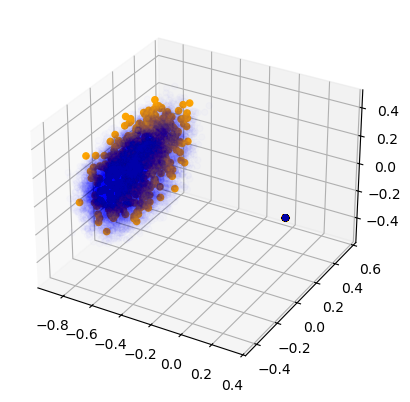

In [44]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(locus_embed3d.T[0], locus_embed3d.T[1], locus_embed3d.T[2], color='orange', alpha=1.0)
ax.scatter(nonlocus_embed3d.T[0], nonlocus_embed3d.T[1], nonlocus_embed3d.T[2], color='blue', alpha=0.01)

plt.show()

Maybe there's something here? It doesn't look quite differentiated, though.

Let's see if we get anything different looking at the Hugo dataset

In [46]:
hugo = train_data[train_data.hugo]
nonhugo = train_data[~(train_data.hugo)]

hugo_embed = transformer.encode(np.array(hugo.book_synopsis))
nonhugo_embed = transformer.encode(np.array(nonhugo.book_synopsis))

In [47]:
hugo3d = pca.transform(hugo_embed)
nonhugo3d = pca.transform(nonhugo_embed)

hugo3d = hugo3d.T
nonhugo3d = nonhugo3d.T

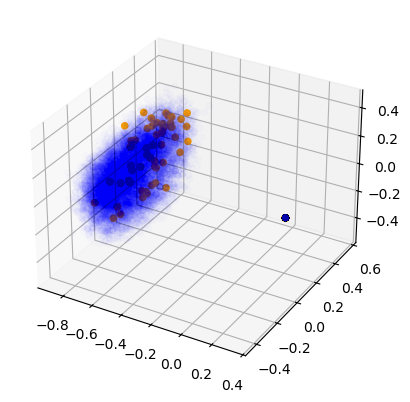

In [49]:
ax = plt.figure().add_subplot(projection= '3d')

ax.scatter(hugo3d[0], hugo3d[1], hugo3d[2], color='orange', alpha = 1.0)
ax.scatter(nonhugo3d[0], nonhugo3d[1], nonhugo3d[2], color='blue', alpha=0.01)

plt.show()